# import

In [3]:
import strawberryfields as sf
from strawberryfields import ops
from strawberryfields.ops import Sgate, BSgate, MeasureFock

from strawberryfields.tdm import shift_by
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.linalg import sqrtm

# fidelity (function)

In [ ]:

def simple_fidelity(rho, sigma):
    """Calculates the Uhlmann-Jozsa fidelity between two density matrices."""
    
    # Ensure inputs are numpy arrays
    rho = np.array(rho)
    sigma = np.array(sigma)
    
    # Calculate the square root of rho
    # sqrtm is the matrix square root, not element-wise
    rho_sqrt = sqrtm(rho)
    
    # Calculate the product inside the trace
    product = rho_sqrt @ sigma @ rho_sqrt
    
    # Calculate the square root of the product
    sqrt_product = sqrtm(product)
    
    # The trace of the result is the "trace distance" part
    # We take the real part to handle potential small imaginary numerical errors
    trace = np.trace(sqrt_product).real
    
    # Fidelity is the square of this trace
    fidelity = trace**2
    
    return fidelity

def robust_fidelity(rho, sigma):
    """
    Calculates the Uhlmann-Jozsa fidelity with enhanced numerical robustness.

    This implementation explicitly uses eigendecomposition and includes steps to
    handle common floating-point precision issues.
    """
    # --- 1. Input Validation and Conditioning ---
    rho = np.asarray(rho, dtype=np.complex128)
    sigma = np.asarray(sigma, dtype=np.complex128)
    
    if rho.shape != sigma.shape or rho.ndim != 2 or rho.shape[0] != rho.shape[1]:
        raise ValueError("Input density matrices must be square and have the same shape.")

    # Enforce Hermiticity on inputs to remove numerical noise
    rho = 0.5 * (rho + rho.T.conj())
    sigma = 0.5 * (sigma + sigma.T.conj())

    # --- 2. Calculate sqrt(rho) Robustly ---
    # eigh is best for Hermitian matrices
    e_vals_rho, e_vecs_rho = np.linalg.eigh(rho)
    
    # Clip small negative eigenvalues to 0 due to numerical instability
    e_vals_rho_clipped = np.maximum(e_vals_rho.real, 0)
    
    # Calculate square root of eigenvalues
    sqrt_e_vals_rho = np.sqrt(e_vals_rho_clipped)
    
    # Reconstruct sqrt(rho) = U * sqrt(D) * U_dagger
    rho_sqrt = e_vecs_rho @ np.diag(sqrt_e_vals_rho) @ e_vecs_rho.T.conj()
    
    # --- 3. Calculate the product matrix K and ensure it's Hermitian ---
    K = rho_sqrt @ sigma @ rho_sqrt
    K = 0.5 * (K + K.T.conj()) # Enforce Hermiticity on the result

    # --- 4. Calculate Tr(sqrt(K)) Robustly ---
    # We only need the eigenvalues of K. Use eigvalsh for efficiency.
    e_vals_K = np.linalg.eigvalsh(K)
    
    # Clip again before the final square root
    e_vals_K_clipped = np.maximum(e_vals_K.real, 0)
    
    # The trace of sqrt(K) is the sum of the square roots of K's eigenvalues
    trace_val = np.sum(np.sqrt(e_vals_K_clipped))
    
    # --- 5. Calculate and Clip Final Fidelity ---
    fidelity = trace_val**2
    
    # Clip the final result to the valid [0, 1] range
    return np.clip(fidelity, 0.0, 1.0)

uhlmann_jozsa_fidelity = simple_fidelity

# fidelity function test

In [97]:

# We need a cutoff dimension to represent states as density matrices.
# A higher cutoff gives better accuracy but is slower.
CUTOFF_DIM = 15 

# Initialize the Strawberry Fields engine and program
eng = sf.Engine("fock", backend_options={"cutoff_dim": CUTOFF_DIM})
prog = sf.Program(1)

print(f"--- Testing Fidelity Function (using cutoff_dim={CUTOFF_DIM}) ---\n")

# ==============================================================================
# --- Test Case 1: Identical States (Expected Fidelity = 1) ---
# ==============================================================================
print("--- Test Case 1: Identical Coherent States |α⟩ and |α⟩ ---")
alpha = 1.2 - 0.5j

# Prepare the state |α⟩
prog = sf.Program(1)
with prog.context as q:
    Coherent(np.abs(alpha), np.angle(alpha)) | q[0]
    
state1 = eng.run(prog).state
rho_1 = state1.dm() # Get the density matrix

# The second state is identical
sigma_1 = rho_1 

# Calculate fidelity
fidelity_1 = uhlmann_jozsa_fidelity(rho_1, sigma_1)

print(f"State: Coherent State α = {alpha}")
print(f"Expected Fidelity: 1.0")
print(f"Calculated Fidelity: {fidelity_1:.8f}\n")
# We can use np.isclose to formally check
assert np.isclose(fidelity_1, 1.0)


# ==============================================================================
# --- Test Case 2: Orthogonal States (Expected Fidelity = 0) ---
# ==============================================================================
print("--- Test Case 2: Orthogonal Fock States |0⟩ and |1⟩ ---")

# Prepare the state |0⟩ (Vacuum)
prog = sf.Program(1)
with prog.context as q:
    Fock(0) | q[0]
    pass
state_vac = eng.run(prog).state
rho_vac = state_vac.dm()

# Prepare the state |1⟩
prog = sf.Program(1)
with prog.context as q:
    Fock(1) | q[0]
state_fock1 = eng.run(prog).state
sigma_fock1 = state_fock1.dm()

# Calculate fidelity
fidelity_2 = uhlmann_jozsa_fidelity(rho_vac, sigma_fock1)

print(f"States: Vacuum |0⟩ and Single-Photon |1⟩")
print(f"Expected Fidelity: 0.0")
print(f"Calculated Fidelity: {fidelity_2:.8f}")
print("(Note: The result may be a very small number like 1e-30 due to floating-point precision)\n")
assert np.isclose(fidelity_2, 0.0)


# ==============================================================================
# --- Test Case 3: Known Intermediate Fidelity (0 < F < 1) ---
# ==============================================================================
print("--- Test Case 3: Two different Coherent States |α⟩ and |β⟩ ---")
alpha = 0.6
beta = -0.6

# 1. Calculate the THEORETICAL fidelity using the known formula
# F = exp(-|α - β|²)
theoretical_fidelity = np.exp(-np.abs(alpha - beta)**2)

# 2. Prepare the states in Strawberry Fields and get their density matrices
prog = sf.Program(1)
with prog.context as q:
    Coherent(np.abs(alpha), np.angle(alpha)) | q[0]
rho_alpha = eng.run(prog).state.dm()

prog = sf.Program(1)
with prog.context as q:
    Coherent(np.abs(beta), np.angle(beta)) | q[0]
sigma_beta = eng.run(prog).state.dm()

# 3. Calculate the fidelity using your function
calculated_fidelity_3 = uhlmann_jozsa_fidelity(rho_alpha, sigma_beta)

print(f"State 1: Coherent |α={alpha}⟩")
print(f"State 2: Coherent |β={beta}⟩")
print(f"Theoretical Fidelity (from formula): {theoretical_fidelity:.8f}")
print(f"Calculated Fidelity (from your function): {calculated_fidelity_3:.8f}\n")
assert np.isclose(theoretical_fidelity, calculated_fidelity_3)

print("--- All tests passed! ---")

--- Testing Fidelity Function (using cutoff_dim=15) ---

--- Test Case 1: Identical Coherent States |α⟩ and |α⟩ ---
State: Coherent State α = (1.2-0.5j)
Expected Fidelity: 1.0
Calculated Fidelity: 1.00000005

--- Test Case 2: Orthogonal Fock States |0⟩ and |1⟩ ---
States: Vacuum |0⟩ and Single-Photon |1⟩
Expected Fidelity: 0.0
Calculated Fidelity: 0.00000000
(Note: The result may be a very small number like 1e-30 due to floating-point precision)

--- Test Case 3: Two different Coherent States |α⟩ and |β⟩ ---
State 1: Coherent |α=0.6⟩
State 2: Coherent |β=-0.6⟩
Theoretical Fidelity (from formula): 0.23692776
Calculated Fidelity (from your function): 0.23692777

--- All tests passed! ---


# visualize cat

Final state: <FockState: num_modes=1, cutoff=50, pure=True, hbar=2>
[]


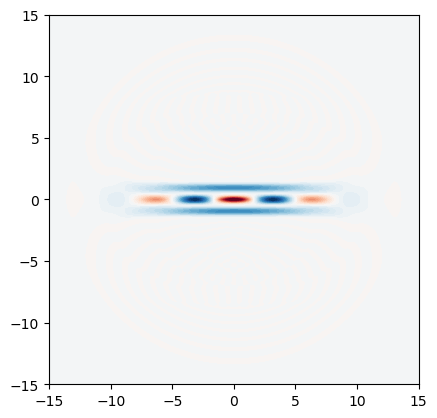

In [4]:

# Same circuit on bosonic and fock backends
prog = sf.Program(1)

# Define the parameters for the squeezed cat state
alpha = 2.40
r = 1.62

# --- 2. Construct the Quantum Circuit ---
with prog.context as q:
    # First, prepare the initial cat state
    # A cat state is a superposition of two coherent states
    Catstate(alpha,p=1) | q[0]
    
    # Second, apply the squeezing operation
    Sgate(r) | q[0]

    Rgate(np.pi/2) | q[0]


# Use the Fock backend (adjust cutoff_dim as needed for convergence)
eng = sf.Engine("fock", backend_options={"cutoff_dim": 50})

# hbar = 2
# eng = sf.Engine("bosonic", backend_options={"hbar": hbar})


result = eng.run(prog)

# Output the final state or relevant results
print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=0, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()                                              # Display the plot


# Practical

## 1 loop circuit (no agent)

Final state: <FockState: num_modes=3, cutoff=30, pure=True, hbar=2>
[[2. 0.]]
Fidelity = 0.9327545864083775


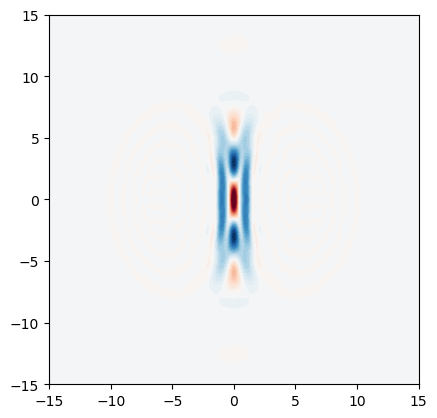

In [7]:
tau =  0.367
theta_bs = np.arccos(tau)
# theta_bs = 1.8
# Squeezing parameter
r = 1.38  # Adjust as needed

# Rotation angle
phi = np.pi/2  # Adjust as needed

# Create a 4-mode quantum program
prog = sf.Program(3)


with prog.context as q:
    # Apply squeezing gates to initialize the states
    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[1]
    ops.BSgate(theta_bs) | (q[0], q[1])
    ops.MeasureFock(select=1) | q[0]

    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[2]
    ops.BSgate(theta_bs) | (q[0], q[2])
    ops.MeasureFock(select=2) | q[0]


    ops.Rgate(phi) | q[2]
    ops.CZgate() | (q[2], q[1])
    ops.MeasureHomodyne(phi=np.pi / 2, select=0) | q[2]


# Use the Fock backend (adjust cutoff_dim as needed for convergence)
cutoff = 30
eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})

result = eng.run(prog)
state_practical = result.state
state_practical_dm = state_practical.reduced_dm(modes=[1])

print("Final state:", result.state)
print(result.samples)


# Same circuit on bosonic and fock backends
eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})
# eng = sf.Engine("bosonic")


prog = sf.Program(1)

# Define the parameters for the squeezed cat state
alpha = 2.40
r = 1.62

# --- 2. Construct the Quantum Circuit ---
with prog.context as q:
    # First, prepare the initial cat state
    # A cat state is a superposition of two coherent states
    Catstate(alpha,p=1) | q[0]
    
    # Second, apply the squeezing operation
    Sgate(r) | q[0]

state_theoretical = eng.run(prog).state
state_theoretical_dm = state_theoretical.dm(cutoff=cutoff)

fid = uhlmann_jozsa_fidelity(state_practical_dm, state_theoretical_dm)
print("Fidelity =", fid)


xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = state_practical.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()                                              # Display the plot



# fidelity with bosonic backend

In [4]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.linalg import sqrtm


# Same circuit on bosonic and fock backends
cutoff = 100
eng_fock = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})
eng_bosonic = sf.Engine("bosonic")

prog = sf.Program(1)

# Define the parameters for the squeezed cat state
alpha = 2.40
r = 1.62

# --- 2. Construct the Quantum Circuit ---
with prog.context as q:
    # First, prepare the initial cat state
    # A cat state is a superposition of two coherent states
    Catstate(alpha,p=1) | q[0]
    
    # Second, apply the squeezing operation
    Sgate(r) | q[0]

state_fock = eng_fock.run(prog).state
state_bosonic = eng_bosonic.run(prog).state

fid = uhlmann_jozsa_fidelity(state_bosonic.dm(cutoff=cutoff), state_fock.dm(cutoff=cutoff))
print("Fidelity =", fid)


Fidelity = 0.4999508239968068


# fock prob of squeezed cat state

Analyzing the ideal state from the bosonic backend...
Calculating Fock probabilities up to n=49 (this may take a moment)...

Total probability captured within the first 50 Fock states: 0.9996
This means 0.0% of the state exists at n >= 50.
Probability of being in state |n=49>: 0.000101


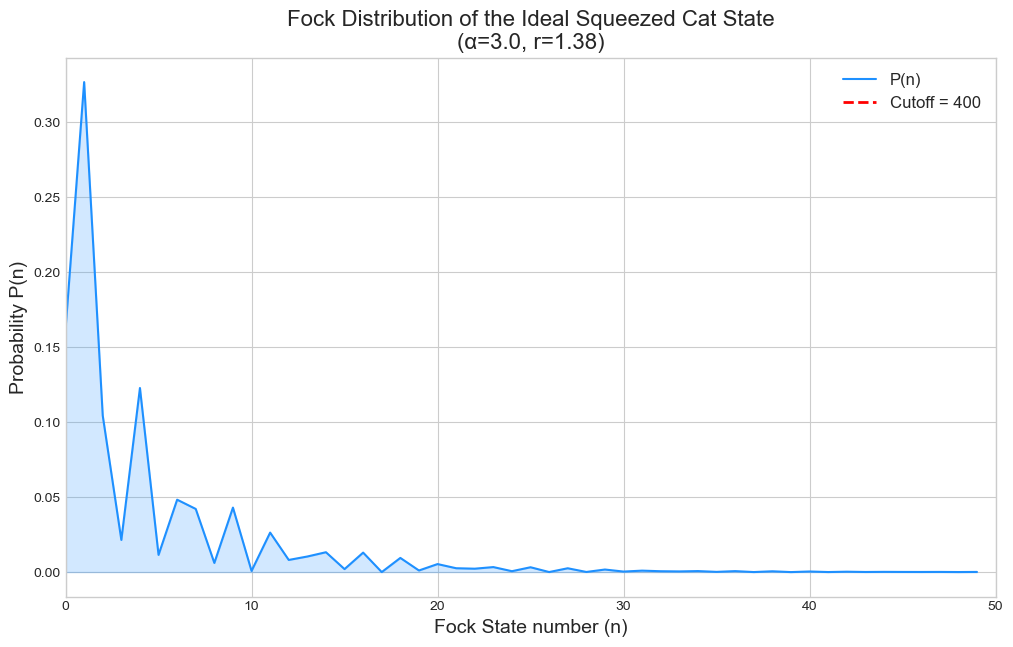

In [31]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
alpha = 3.0
r = 1.38
MAX_N_TO_CHECK = 50 # Let's check the probabilities up to n=500

# --- State Preparation with the EXACT Bosonic Backend ---
eng_bosonic = sf.Engine("bosonic")
prog = sf.Program(1)
with prog.context as q:
    Catstate(alpha) | q[0]
    Sgate(r) | q[0]

# Run the simulation to get the ideal state
bosonic_result = eng_bosonic.run(prog)
ideal_state = bosonic_result.state

print("Analyzing the ideal state from the bosonic backend...")

# --- Calculate Fock probabilities from the ideal state ---
# CORRECTION 2: We must provide a 'cutoff' kwarg to fock_prob that is
# larger than any 'n' we are testing.

print(f"Calculating Fock probabilities up to n={MAX_N_TO_CHECK-1} (this may take a moment)...")

fock_indices = np.arange(MAX_N_TO_CHECK)
probabilities = [] # Use a list to store results

for n in fock_indices:
    # Pass [n] and the cutoff argument to the method
    prob_n = ideal_state.fock_prob([n], cutoff=MAX_N_TO_CHECK) 
    probabilities.append(prob_n)

# Convert the list of probabilities to a NumPy array for analysis
probabilities = np.array(probabilities)

# --- Analysis and Plotting (this part is unchanged) ---
# Calculate the cumulative probability to see how much of the state we've captured
cumulative_prob = np.sum(probabilities)
print(f"\nTotal probability captured within the first {MAX_N_TO_CHECK} Fock states: {cumulative_prob:.4f}")
print(f"This means {(1-cumulative_prob)*100:.1f}% of the state exists at n >= {MAX_N_TO_CHECK}.")
print(f"Probability of being in state |n={MAX_N_TO_CHECK-1}>: {probabilities[-1]:.6f}")

# --- Plotting the Results ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(fock_indices, probabilities, color='dodgerblue', label='P(n)')
ax.fill_between(fock_indices, probabilities, color='dodgerblue', alpha=0.2)

# Highlight the cutoff of 400
ax.axvline(x=400, color='red', linestyle='--', linewidth=2, label='Cutoff = 400')

ax.set_xlabel("Fock State number (n)", fontsize=14)
ax.set_ylabel("Probability P(n)", fontsize=14)
ax.set_title(f"Fock Distribution of the Ideal Squeezed Cat State\n(α={alpha}, r={r})", fontsize=16)
ax.set_xlim(0, MAX_N_TO_CHECK)
ax.legend(fontsize=12)
plt.show()